<a href="https://colab.research.google.com/github/Marahamj/Comprehensive-Data-Science-Medical-Costs-Quality-Analytics/blob/main/assiment_ai_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 1 course Ai

using NumPy, Pandas and Matplotlib. This lab will build foundational skills needed for future
AI model development




**Name : Marah A Qandeel**

**Num: 2320226461**


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Import Data**

In [95]:
df = pd.read_csv('titanic.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# **Data Explortion **



In [96]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [97]:
df.shape

(891, 15)

## Data Analysis



 columns in dataset
 **

1-survived  
**Values:** 0 = did not survive, 1 = survived  

This is the **Target** (the label/هدف) in the analysis or machine learning.  
All analysis is done to understand: **why did some people survive?**

### 2. **pclass** Numerical

**Values:** 1 = First class
, 2 = Second,
3 = Third  

An indicator of economic and social status.  
Usually:  
First class → higher chance of survival.


### 3. **sex**
**Values:** male / female  

One of the most important factors.  
Historically:  
“Women and children first” → women had a higher survival rate.



### 4. **age**
Numerical
**Values:** passenger’s age  
Children usually have a higher chance of survival.  
Important for statistical analysis.



### 5. **sibsp**
Numerical
**Values:** number of siblings/spouses on board  

Measures family relationships.  
Having family may help or hinder survival.



### 6. **parch**
Numerical
**Values:** number of parents/children    
Complements `sibsp`.  
 Helps you understand whether the person was with family.

### 7. **fare**
**Values:** ticket price  

Related to:  
 Class (`pclass`)  
 Comfort/wealth level  
 The higher the price, the more likely survival.



### 8. **embarked**
**Values:**  
- C = Cherbourg  
- Q = Queenstown  
- S = Southampton  
**Importance:**  
Port of embarkation (boarding).  
→ May be linked to the type of passengers (class / gender).



## Additional descriptive columns

### 9. **class**
Text description of `pclass` (First / Second / Third)   
Just a textual representation (duplicate).


### 10. **who**
**Values:** man / woman / child   
A simplified category derived from `age` and `sex`.

### 11. **adult_male**
True / False   
Indicates whether the person is:  
an adult man  
 Important because this group had the lowest survival luck.


### 12. **deck**
**Values:** A, B, C...   
Cabin location on the ship.  
 Could affect how quickly people reached lifeboats  


### 13. **embark_town**
Name of the city instead of the code  
Same as `embarked` but clearer.

### 14. **alive**
yes / no   
Same as `survived`, but in text form _(duplicate)._



### 15. **alone**
True / False  
Whether the person was alone.  
Important for analyzing the impact of family.


**Data cleaning **

In [98]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [99]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


age

In [100]:
df['age']=df['age'].fillna(df['age'].mean())

In [101]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

The deck column was removed because it contained a large proportion of missing values, making it unreliable for analysis and potentially introducing bias or noise into the results.

In [102]:

df.drop('deck',axis=1,inplace=True)

In [103]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


**Duplicate Values**

In [104]:
print(f"dublicated value : {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

dublicated value : 111


In [105]:
print(f"dublicated value : {df.duplicated().sum()}")

dublicated value : 0


عندما وضعت جميع القيم الرقمية في رسمة واحدة تبين انه فيه قيم صغيرة وقيم كبيرة ففصلت حتى تظهر بشكل واضح القيم الشاذة

Outliers

Text(0.5, 1.0, 'Boxplot the titinc dataset to explor the outliers')

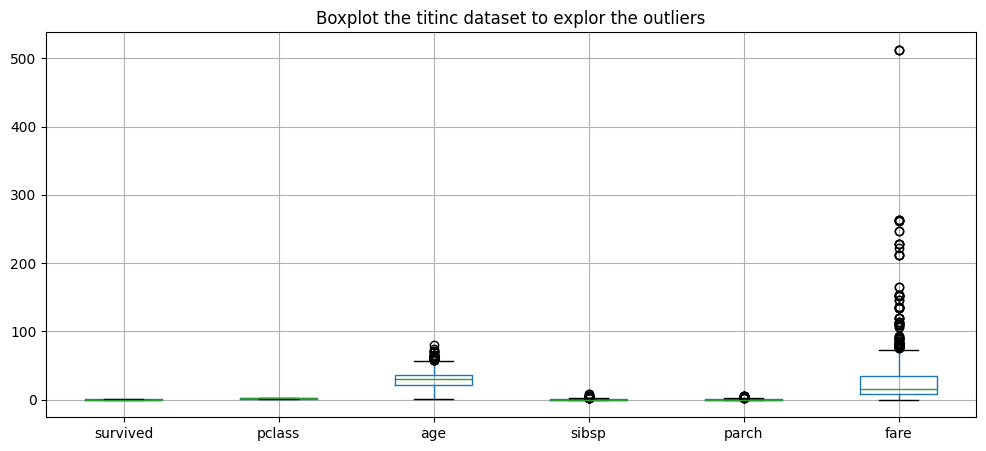

In [106]:

num_columns= df.select_dtypes(include=["float64","int64","int32"]).columns
plt.figure(figsize=(12,5))
df[num_columns].boxplot()
plt.title("Boxplot the titinc dataset to explor the outliers")



القيم الشاذة عندي ال age ,fare لا

"نحن نقول للبرنامج: خذ عمود العمر وعمود الأجرة، احسب المدى اللي معظم البيانات فيه (من الربع الأول للربع الثالث)، ثم حدد قيمة طبيعية كبيرة وقيمة طبيعية صغيرة. أي رقم أكبر من الكبير نخليه زي الكبير، وأي رقم أصغر من الصغير نخليه زي الصغير. كده بنخلي القيم الشاذة تبقى ضمن الحدود الطبيعية."



In [107]:
#
outlier_cols = ['age', 'fare']
for col in outlier_cols:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   df[col] = df[col].clip(lower, upper)


Analyze survival rates based on gender and visualize them.

Sex data was collected and categorized by survival or death, then plotted using a bar chart from the Seaborn library.

sex
female    73.972603
male      21.721311
Name: survived, dtype: float64


Text(0.5, 0, 'Gender')

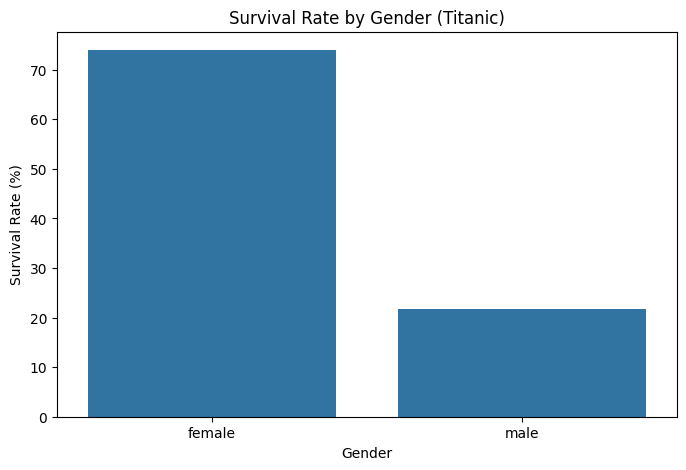

In [108]:
suverid_bySex = df.groupby("sex")["survived"].mean()*100
print(suverid_bySex)

plt.figure(figsize=(8,5))
sns.barplot(x=suverid_bySex.index, y=suverid_bySex.values)
plt.title('Survival Rate by Gender (Titanic)')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Gender')

الإناث: حوالي 74% من الركاب الإناث نجوا.

الذكور: حوالي 22% من الركاب الذكور نجوا.



. Create a histogram of passenger ages.

Text(0, 0.5, 'Frequency')

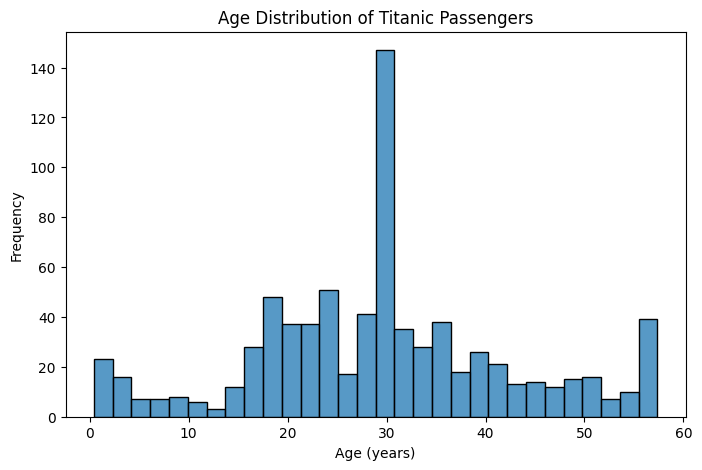

In [109]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, edgecolor='black')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')

The age histogram showed that the majority of Titanic passengers were in the 20-30 age group, with approximately 140 passengers. The number gradually decreases for older ages, with few elderly people and children. This indicates that the passengers tended to be young.